In [1]:
# Using Chemical Language transformer model for Molecular Property prediction
# ADME (Absorption, Distribution, Metabolism, and Excretion) 

In [2]:
# https://dmol.pub/dl/gnn.html : Graph Neural Networks

In [3]:
# https://www.nature.com/articles/s41467-023-38192-3

In [4]:
# https://medium.com/@tejpal.abhyuday/application-of-gnn-for-calculating-the-solubility-of-molecule-graph-level-prediction-8bac5fabf600

In [5]:
# https://medium.com/@nikopavl4/pytorch-geometric-for-graph-based-molecular-property-prediction-using-moleculenet-benchmark-41e36369d3c6

In [6]:
# https://pharmanalytics.medium.com/using-chemical-language-transformer-model-for-molecular-property-prediction-regression-tasks-5d617aba4639

In [7]:
# https://medium.com/@mulugetas/drug-discovery-and-graph-neural-networks-gnns-a-regression-example-fc738e0f11f3

In [8]:
# MOLECULE NET : https://moleculenet.org/

In [9]:
# https://arxiv.org/abs/1703.00564

In [10]:
# DEEPCHEM
# https://github.com/deepchem/deepchem

In [11]:
# MoleculeNet is built upon multiple public databases. 
# The full collection currently includes over 700,000 compounds tested on a range of different properties. 
# We test the performances of various machine learning models with different featurizations on the datasets 
# (detailed descriptions here), with all results reported in AUC-ROC, AUC-PRC, RMSE and MAE scores.

In [12]:
# Tox21 dataset
# The Tox21 dataset is a collection of information about the potential toxicity of various chemical compounds.

In [13]:
# https://github.com/nikopavl4/MediumArticlesNotebooks/blob/main/PyG_and_Moleculenet_Graph_Classification.ipynb

In [14]:
import torch
from torch_geometric.datasets import MoleculeNet

dataset = MoleculeNet(root=".", name="Tox21")

print()
print(f'Dataset: {dataset}:')
print('====================')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

data = dataset[0]  # Get the first graph object.

print()
print(data)
print('=============================================================')

# Gather some statistics about the first graph.
print(f'Number of nodes: {data.num_nodes}')
print(f'Number of edges: {data.num_edges}')
print(f'Average node degree: {data.num_edges / data.num_nodes:.2f}')
print(f'Has isolated nodes: {data.has_isolated_nodes()}')
print(f'Has self-loops: {data.has_self_loops()}')
print(f'Is undirected: {data.is_undirected()}')


Dataset: Tox21(7823):
Number of graphs: 7823
Number of features: 9
Number of classes: 12

Data(x=[16, 9], edge_index=[2, 34], edge_attr=[34, 3], smiles='CCOc1ccc2nc(S(N)(=O)=O)sc2c1', y=[1, 12])
Number of nodes: 16
Number of edges: 34
Average node degree: 2.12
Has isolated nodes: False
Has self-loops: False
Is undirected: True


In [15]:
data

Data(x=[16, 9], edge_index=[2, 34], edge_attr=[34, 3], smiles='CCOc1ccc2nc(S(N)(=O)=O)sc2c1', y=[1, 12])

In [16]:
# List every attribute the Data object holds
print(data.keys())           # ['x', 'edge_index', 'edge_attr', 'smiles', 'y']

['smiles', 'x', 'edge_attr', 'edge_index', 'y']


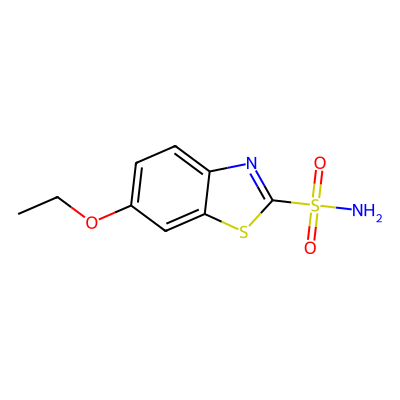

In [17]:
from rdkit import Chem
from rdkit.Chem.Draw import MolToImage

mol = Chem.MolFromSmiles(data.smiles)
img = MolToImage(mol, size=(400, 400))
# img.save("molecule_0.png")
img

In [18]:
# Node features: one row per atom, 9 chemical descriptors per atom
print(data.x)
print(data.x.shape)          # torch.Size([16, 9])

tensor([[ 6,  0,  4,  5,  3,  0,  4,  0,  0],
        [ 6,  0,  4,  5,  2,  0,  4,  0,  0],
        [ 8,  0,  2,  5,  0,  0,  3,  0,  0],
        [ 6,  0,  3,  5,  0,  0,  3,  1,  1],
        [ 6,  0,  3,  5,  1,  0,  3,  1,  1],
        [ 6,  0,  3,  5,  1,  0,  3,  1,  1],
        [ 6,  0,  3,  5,  0,  0,  3,  1,  1],
        [ 7,  0,  2,  5,  0,  0,  3,  1,  1],
        [ 6,  0,  3,  5,  0,  0,  3,  1,  1],
        [16,  0,  4,  5,  0,  0,  4,  0,  0],
        [ 7,  0,  3,  5,  2,  0,  4,  0,  0],
        [ 8,  0,  1,  5,  0,  0,  3,  0,  0],
        [ 8,  0,  1,  5,  0,  0,  3,  0,  0],
        [16,  0,  2,  5,  0,  0,  3,  1,  1],
        [ 6,  0,  3,  5,  0,  0,  3,  1,  1],
        [ 6,  0,  3,  5,  1,  0,  3,  1,  1]])
torch.Size([16, 9])


In [19]:
# To decode the 9 atom-feature columns into something meaningful, the columns come from OGB's atom_to_feature_vector and are in this order: 
# atomic number, chirality, degree, formal charge, num H's, num radical electrons, hybridization, is aromatic, is in ring. 
# So for the first atom in your output [6, 0, 4, 5, 3, 0, 4, 0, 0]: atomic number 6 (carbon), 
# no chirality, degree 4, formal charge offset 5 (= 0 — the encoding shifts negative charges into positive integers), 3 hydrogens, etc.

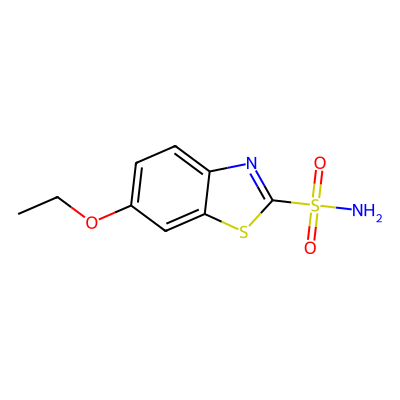

In [20]:
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit import Chem
from rdkit.Chem.Draw import MolToImage

mol = Chem.MolFromSmiles(data.smiles)
MolToImage(mol, size=(400, 400))

In [21]:
# The shape [1, 12] means one molecule, twelve targets. 
# Tox21 measured each compound against 12 different toxicity assays in the lab, 
# so every molecule gets a 12-element label vector. Three possible values:

# 0. → the molecule was tested and is not toxic for that pathway
# 1. → the molecule was tested and is toxic (it activated that pathway)
# nan → that assay was never run for this molecule (missing data)

data.y

tensor([[0., 0., 1., nan, nan, 0., 0., 1., 0., 0., 0., 0.]])

In [22]:
# AssayValueMeaning

# 1NR-AR (Androgen Receptor) 0 inactive
# 2NR-AR-LBD (AR Ligand Binding Domain) 0 inactive
# 3NR-AhR (Aryl hydrocarbon Receptor) 1 active
# 4NR-Aromatase nan not tested
# 5NR-ER (Estrogen Receptor) nan not tested
# 6NR-ER-LBD (ER Ligand Binding Domain) 0 inactive
# 7NR-PPAR-gamma 0 inactive
# 8SR-ARE (Antioxidant Response Element) 1 active
# 9SR-ATAD5 (DNA damage) 0 inactive
# 10SR-HSE (Heat Shock Element) 0 inactive
# 11SR-MMP (Mitochondrial Membrane Potential) 0 inactive
# 12SR-p53 (tumor suppressor stress) 0 inactive

In [23]:
# Edges as pairs of atom indices: row 0 = source atoms, row 1 = destination atoms
print(data.edge_index)
print(data.edge_index.shape) # torch.Size([2, 34])

tensor([[ 0,  1,  1,  2,  2,  3,  3,  3,  4,  4,  5,  5,  6,  6,  6,  7,  7,  8,
          8,  8,  9,  9,  9,  9, 10, 11, 12, 13, 13, 14, 14, 14, 15, 15],
        [ 1,  0,  2,  1,  3,  2,  4, 15,  3,  5,  4,  6,  5,  7, 14,  6,  8,  7,
          9, 13,  8, 10, 11, 12,  9,  9,  9,  8, 14,  6, 13, 15,  3, 14]])
torch.Size([2, 34])


In [24]:
# Two rows: the first lists source atom indices, the second lists destination atom indices. 
# So edge_index[:, k] gives you the k-th edge as a (source, target) pair

src, dst = data.edge_index
for s, d in zip(src.tolist(), dst.tolist()):
    print(f"atom {s} -> atom {d}")

atom 0 -> atom 1
atom 1 -> atom 0
atom 1 -> atom 2
atom 2 -> atom 1
atom 2 -> atom 3
atom 3 -> atom 2
atom 3 -> atom 4
atom 3 -> atom 15
atom 4 -> atom 3
atom 4 -> atom 5
atom 5 -> atom 4
atom 5 -> atom 6
atom 6 -> atom 5
atom 6 -> atom 7
atom 6 -> atom 14
atom 7 -> atom 6
atom 7 -> atom 8
atom 8 -> atom 7
atom 8 -> atom 9
atom 8 -> atom 13
atom 9 -> atom 8
atom 9 -> atom 10
atom 9 -> atom 11
atom 9 -> atom 12
atom 10 -> atom 9
atom 11 -> atom 9
atom 12 -> atom 9
atom 13 -> atom 8
atom 13 -> atom 14
atom 14 -> atom 6
atom 14 -> atom 13
atom 14 -> atom 15
atom 15 -> atom 3
atom 15 -> atom 14


In [25]:
# Edge features: 3 descriptors per bond (bond type, stereo, conjugation)
print(data.edge_attr)
print(data.edge_attr.shape)  # torch.Size([34, 3])

tensor([[ 1,  0,  0],
        [ 1,  0,  0],
        [ 1,  0,  0],
        [ 1,  0,  0],
        [ 1,  0,  1],
        [ 1,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [ 1,  0,  0],
        [12,  0,  1],
        [ 1,  0,  0],
        [ 1,  0,  0],
        [ 2,  0,  0],
        [ 2,  0,  0],
        [ 1,  0,  0],
        [ 2,  0,  0],
        [ 2,  0,  0],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1],
        [12,  0,  1]])
torch.Size([34, 3])


In [26]:
data.smiles

'CCOc1ccc2nc(S(N)(=O)=O)sc2c1'

In [27]:
# Labels: 12 toxicity targets for this molecule (NaN where unlabeled)

print(data.y)
print(data.y.shape)          # torch.Size([1, 12])

# The shape [1, 12] means one molecule, twelve targets. 
# Tox21 measured each compound against 12 different toxicity assays in the lab, 
# so every molecule gets a 12-element label vector. Three possible values:

# 0. → the molecule was tested and is not toxic for that pathway
# 1. → the molecule was tested and is toxic (it activated that pathway)
# nan → that assay was never run for this molecule (missing data)

tensor([[0., 0., 1., nan, nan, 0., 0., 1., 0., 0., 0., 0.]])
torch.Size([1, 12])


In [28]:
print(dataset)

Tox21(7823)


In [29]:
# We notice that the dataset contains 7831 graphs and every graph has nodes with 9 features. But what are these node features? According to literature, we have:

# Atomic number: The atomic number of an atom is the number of protons in its nucleus and determines its place in the periodic table.
# Chirality: A molecule is chiral if it cannot be superimposed on its mirror image through rotations, translations, or certain conformational changes. There are different types of chirality depending on the molecule and the arrangement of its atoms.
# Degree: The degree of an atom is the number of atoms it is directly bonded to.
# Formal charge: The formal charge of an atom is a charge assigned to it based on its electron count compared to that of an isolated, neutral atom.
# Number of H: The number of H refers to the total number of hydrogen atoms on the atom.
# Number of radical e: The number of radical e refers to the number of unpaired electrons on the atom.
# Hybridization: Hybridization refers to the type of hybrid orbitals that an atom’s valence electrons are arranged in.
# Is aromatic: Aromaticity refers to the presence of pi bonds in a cyclic structure, which tends to be more stable than other geometric arrangements of the same atoms.
# Is in ring: Being in a ring refers to being part of a simple cycle of atoms and bonds in a molecule.

In [30]:
 print("Feature Engineering:")

Feature Engineering:


In [31]:
# We have 16 nodes (rows) and each node has 9 features (columns). 

# The features provided by Moleculenet are discrete and of type long, 
# so we need to convert them first to continuous embeddings in order to feed them in any ML model. 
    
# There are a variety of methods available for producing continuous embeddings. 
# However, for the purposes of simplicity, we will utilize the PyTorch Embedding module within an AtomEncoder function to accomplish this task.

In [32]:
class AtomEncoder(torch.nn.Module):
    def __init__(self, hidden_channels):
        super(AtomEncoder, self).__init__()

        self.embeddings = torch.nn.ModuleList()

        for i in range(dataset.num_features):
            self.embeddings.append(torch.nn.Embedding(100, hidden_channels))

    def reset_parameters(self):
        for embedding in self.embeddings:
            embedding.reset_parameters()

    def forward(self, x):
        if x.dim() == 1:
            x = x.unsqueeze(1)

        out = 0
        for i in range(x.size(1)):
            out += self.embeddings[i](x[:, i])
        return out

In [33]:
# Create a toy sample of AtomEncoder
SimpleEncoder = AtomEncoder(hidden_channels=32)
# Print the embeddings weight matrix for the first feature
print(SimpleEncoder.embeddings[0].weight)
# The result after first graph passes the AtomEncoder
print(SimpleEncoder(data.x))

Parameter containing:
tensor([[-0.7068, -0.2156,  1.8246,  ...,  2.3309, -0.0351, -0.2878],
        [-0.8485,  0.1776,  0.7495,  ..., -0.3594,  0.7050,  1.1286],
        [-0.6161, -0.2903,  1.2570,  ..., -2.2833, -1.7761,  0.7550],
        ...,
        [ 0.5558,  0.5414, -0.3059,  ..., -1.1730, -0.0037,  0.2936],
        [-0.3673,  0.8250,  0.0599,  ...,  0.3603,  1.3555,  0.1314],
        [-0.9000, -1.5419,  1.3979,  ..., -1.0229,  0.6770,  1.0054]],
       requires_grad=True)
tensor([[-3.5393e+00, -4.1547e+00, -4.8338e+00, -1.0028e+00,  2.3818e+00,
         -5.7595e-01, -7.6698e+00,  1.9349e+00, -2.8192e+00,  4.2716e+00,
          2.4737e+00, -2.6235e-01, -2.2035e-01, -9.2910e+00,  1.7691e+00,
          2.5383e-01,  3.1724e+00, -1.9494e+00, -2.3915e+00,  1.7985e+00,
          3.5469e+00, -1.8578e-01, -3.4893e+00, -2.4726e+00, -3.4144e+00,
          2.2893e+00, -5.2832e+00,  3.0765e+00,  1.5484e+00,  2.0119e+00,
          2.4209e+00, -1.3077e+00],
        [-3.0947e+00, -1.8160e+00, -4

In [34]:
# First output: the embedding weight matrix.

In [35]:
SimpleEncoder.embeddings

ModuleList(
  (0-8): 9 x Embedding(100, 32)
)

In [36]:
# [
#    Embedding(100, 32),   # for feature column 0 (atomic number)
#    Embedding(100, 32),   # for feature column 1 (chirality)
#    Embedding(100, 32),   # for feature column 2 (degree)
#    Embedding(100, 32),   # for feature column 3 (formal charge)
#    Embedding(100, 32),   # for feature column 4 (num H)
#    Embedding(100, 32),   # for feature column 5 (num radical e-)
#    Embedding(100, 32),   # for feature column 6 (hybridization)
#    Embedding(100, 32),   # for feature column 7 (is aromatic)
#    Embedding(100, 32),   # for feature column 8 (is in ring)
# ]

# Why 9? Because data.x has 9 columns (dataset.num_features == 9) — one embedding table per atom-feature column. 
#    The constructor literally loops for i in range(dataset.num_features).
# Embedding(100, 32) is the actual lookup table. The two numbers are:

# 100 = num_embeddings, the size of the "vocabulary". 
# The table has 100 rows, one per possible integer input. 
# The code picks 100 as a safe upper bound — it just needs to be larger than the max value any feature column will ever take. 
# Atomic numbers go up to maybe 35 (bromine) in drug-like molecules, hybridization is a small enum, etc. 
# — 100 is overkill but harmless.

# 32 = embedding_dim, the size of each output vector. 
# This is hidden_channels passed when constructing the encoder. 
# Every integer input gets mapped to a 32-dimensional dense vector.

In [37]:
# This is SimpleEncoder.embeddings[0].weight, the lookup table for just the first of the 9 atom-feature columns. 
# Its shape is [100, 32] — 100 rows because the code defensively allocates 100 possible values per feature 
# (atomic numbers won't ever reach 100, but it's safe headroom), and 32 columns because that's hidden_channels. 
# Each row is the learned dense vector representing one possible discrete value of feature 0. 
# The values are random because the model hasn't been trained yet — requires_grad=True means these will be updated 
# by gradient descent during training, just like any other learnable parameter.

In [38]:
type(SimpleEncoder.embeddings[0])

torch.nn.modules.sparse.Embedding

In [39]:
# dir(SimpleEncoder.embeddings[0])

In [40]:
# Total parameter count in this whole embeddings ModuleList: 9 tables × 100 rows × 32 dims = 28,800 learnable scalars. 
# They start out randomly initialized and are trained jointly with the GCN layers.

In [41]:
# "Hidden channels" is the dimensionality of the internal representations the network uses between layers — 
# the size of the vectors that aren't the input or the … 
# "Hidden channels" is the dimensionality of the internal representations the network uses between layers — 
# the size of the vectors that aren't the input or the output. It's a tunable hyperparameter you set when building the model.

In [42]:
print('''
data.x          shape: [N, 9]    ← input: 9 integer atom features per atom
  ↓ AtomEncoder(hidden_channels=32)
embedded x      shape: [N, 32]   ← 32-dim continuous vector per atom
  ↓ GCNConv(32, 32)
after conv1     shape: [N, 32]
  ↓ GCNConv(32, 32)
after conv2     shape: [N, 32]
  ↓ GCNConv(32, 32)
after conv3     shape: [N, 32]
  ↓ global_mean_pool
pooled          shape: [batch, 32]   ← one vector per molecule
  ↓ Linear(32, 12)
logits          shape: [batch, 12]   ← output: 12 toxicity predictions
''')


data.x          shape: [N, 9]    ← input: 9 integer atom features per atom
  ↓ AtomEncoder(hidden_channels=32)
embedded x      shape: [N, 32]   ← 32-dim continuous vector per atom
  ↓ GCNConv(32, 32)
after conv1     shape: [N, 32]
  ↓ GCNConv(32, 32)
after conv2     shape: [N, 32]
  ↓ GCNConv(32, 32)
after conv3     shape: [N, 32]
  ↓ global_mean_pool
pooled          shape: [batch, 32]   ← one vector per molecule
  ↓ Linear(32, 12)
logits          shape: [batch, 12]   ← output: 12 toxicity predictions



In [43]:
print('''

The 9 (input features) and 12 (output classes) are fixed by the task. 
The 32 is a design choice — the model squeezes everything into 32 numbers per atom while it's "thinking", 
then projects back out to 12 at the very end. 

Those 32-dim vectors live inside the network and aren't directly interpretable, which is why they're called "hidden" — 
they're the model's internal scratchpad.

Why "channels"? The name comes from convolutional networks for images. A 224×224 RGB image is [3, 224, 224] — 
three input channels (R, G, B). 

After a conv layer with 64 output channels, it becomes [64, 224, 224] — 
64 learned feature maps at each pixel. 

GNN libraries borrowed the word because the math is analogous: 
per node, you have a vector whose length is the "channel count", and each conv layer transforms that vector. 

You'll see the same idea called hidden_dim, hidden_size, d_model, or embedding_dim in other libraries — 
they all mean the same thing.

''')



The 9 (input features) and 12 (output classes) are fixed by the task. 
The 32 is a design choice — the model squeezes everything into 32 numbers per atom while it's "thinking", 
then projects back out to 12 at the very end. 

Those 32-dim vectors live inside the network and aren't directly interpretable, which is why they're called "hidden" — 
they're the model's internal scratchpad.

Why "channels"? The name comes from convolutional networks for images. A 224×224 RGB image is [3, 224, 224] — 
three input channels (R, G, B). 

After a conv layer with 64 output channels, it becomes [64, 224, 224] — 
64 learned feature maps at each pixel. 

GNN libraries borrowed the word because the math is analogous: 
per node, you have a vector whose length is the "channel count", and each conv layer transforms that vector. 

You'll see the same idea called hidden_dim, hidden_size, d_model, or embedding_dim in other libraries — 
they all mean the same thing.




In [44]:
print(SimpleEncoder(data.x))

tensor([[-3.5393e+00, -4.1547e+00, -4.8338e+00, -1.0028e+00,  2.3818e+00,
         -5.7595e-01, -7.6698e+00,  1.9349e+00, -2.8192e+00,  4.2716e+00,
          2.4737e+00, -2.6235e-01, -2.2035e-01, -9.2910e+00,  1.7691e+00,
          2.5383e-01,  3.1724e+00, -1.9494e+00, -2.3915e+00,  1.7985e+00,
          3.5469e+00, -1.8578e-01, -3.4893e+00, -2.4726e+00, -3.4144e+00,
          2.2893e+00, -5.2832e+00,  3.0765e+00,  1.5484e+00,  2.0119e+00,
          2.4209e+00, -1.3077e+00],
        [-3.0947e+00, -1.8160e+00, -4.3803e+00, -1.7244e+00,  2.2016e+00,
          2.8303e+00, -7.8965e+00, -5.5053e-01, -6.0346e-01,  5.0354e+00,
          2.9692e+00,  3.6916e-01,  1.3101e+00, -6.8027e+00,  1.4875e+00,
          1.0782e+00,  1.8660e+00,  9.5438e-01, -2.9807e+00,  3.0031e+00,
          1.2421e+00,  2.8854e-01, -3.3357e+00, -4.0999e+00, -1.6817e+00,
          7.8929e-01, -4.2579e+00,  1.4764e+00,  3.7355e+00,  2.7430e+00,
          1.4304e+00, -1.9337e+00],
        [-4.7297e+00, -6.1206e+00, -2.64

In [45]:
SimpleEncoder.embeddings[0].weight

# The numbers are randomly initialized. They're the parameters the model will learn. 
# This is the weight matrix of one of the nine embedding layers — specifically the one for feature column 0 (atomic number)

Parameter containing:
tensor([[-0.7068, -0.2156,  1.8246,  ...,  2.3309, -0.0351, -0.2878],
        [-0.8485,  0.1776,  0.7495,  ..., -0.3594,  0.7050,  1.1286],
        [-0.6161, -0.2903,  1.2570,  ..., -2.2833, -1.7761,  0.7550],
        ...,
        [ 0.5558,  0.5414, -0.3059,  ..., -1.1730, -0.0037,  0.2936],
        [-0.3673,  0.8250,  0.0599,  ...,  0.3603,  1.3555,  0.1314],
        [-0.9000, -1.5419,  1.3979,  ..., -1.0229,  0.6770,  1.0054]],
       requires_grad=True)

In [46]:
SimpleEncoder.embeddings[0].weight.shape

torch.Size([100, 32])

In [47]:
SimpleEncoder(data.x)

tensor([[-3.5393e+00, -4.1547e+00, -4.8338e+00, -1.0028e+00,  2.3818e+00,
         -5.7595e-01, -7.6698e+00,  1.9349e+00, -2.8192e+00,  4.2716e+00,
          2.4737e+00, -2.6235e-01, -2.2035e-01, -9.2910e+00,  1.7691e+00,
          2.5383e-01,  3.1724e+00, -1.9494e+00, -2.3915e+00,  1.7985e+00,
          3.5469e+00, -1.8578e-01, -3.4893e+00, -2.4726e+00, -3.4144e+00,
          2.2893e+00, -5.2832e+00,  3.0765e+00,  1.5484e+00,  2.0119e+00,
          2.4209e+00, -1.3077e+00],
        [-3.0947e+00, -1.8160e+00, -4.3803e+00, -1.7244e+00,  2.2016e+00,
          2.8303e+00, -7.8965e+00, -5.5053e-01, -6.0346e-01,  5.0354e+00,
          2.9692e+00,  3.6916e-01,  1.3101e+00, -6.8027e+00,  1.4875e+00,
          1.0782e+00,  1.8660e+00,  9.5438e-01, -2.9807e+00,  3.0031e+00,
          1.2421e+00,  2.8854e-01, -3.3357e+00, -4.0999e+00, -1.6817e+00,
          7.8929e-01, -4.2579e+00,  1.4764e+00,  3.7355e+00,  2.7430e+00,
          1.4304e+00, -1.9337e+00],
        [-4.7297e+00, -6.1206e+00, -2.64

In [48]:
SimpleEncoder(data.x).shape

torch.Size([16, 32])

In [49]:
# This is the output of running this specific molecule's atoms through the encoder. Its shape is [16, 32]:

# 16 rows — one row per atom in this molecule (the example molecule has 16 atoms).
# 32 columns — the 32-dimensional vector representing that atom.

In [50]:
# Each row was computed by taking that atom's 9 integer features,
# looking each one up in its corresponding embedding table, and summing the 9 vectors:

# atom 0's vector  =  table_0[atomic_number]
#                 +  table_1[chirality]
#                 +  table_2[degree]
#                 +  ... 6 more lookups ...
#                 +  table_8[in_ring]

In [51]:
print(''' 

Model Initialization Graph Convolutional Network (GCN)

''')


 

Model Initialization Graph Convolutional Network (GCN)




In [52]:
# In a graph convolution operation, the values of the input data are weighted and combined 
# in a way that takes into account the structure of the graph. 
# This allows GCNs to effectively capture the relationships between the nodes and edges of the graph, 
# and use this information to make predictions or perform other tasks.

In [53]:
from torch_geometric.nn import GCNConv
from torch_geometric.nn import global_mean_pool as gap
import torch.nn.functional as F
from torch.nn import Linear

class GCN(torch.nn.Module):
    def __init__(self, hidden_channels, num_node_features, num_classes):
        super(GCN, self).__init__()
        torch.manual_seed(12345)
        self.emb = AtomEncoder(hidden_channels=32)
        self.conv1 = GCNConv(hidden_channels,hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        self.lin = Linear(hidden_channels, num_classes)

    def forward(self,batch):
        x , edge_index, batch_size = batch.x, batch.edge_index, batch.batch
        x = self.emb(x)
        # 1. Obtain node embeddings 
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = self.conv2(x, edge_index)
        x = x.relu()
        x = self.conv3(x, edge_index)

        # 2. Readout layer
        x = gap(x, batch_size)  # [batch_size, hidden_channels]
        # 3. Apply a final classifier
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)
        return x

In [54]:
print('''

┌─────────────────────────────────┐
│  SMILES string                  │
│  CCOc1ccc2nc(S(N)(=O)=O)sc2c1   │
│  (human-readable structure)     │
└─────────────────────────────────┘
              │
              ▼  RDKit parses bonds and atoms
┌─────────────────────────────────┐
│  Molecular graph                │
│  x          : [16, 9]           │  ← 16 atoms × 9 integer features
│  edge_index : [2, 34]           │  ← 17 bonds, stored bidirectionally
│  edge_attr  : [34, 3]           │  ← bond type, stereo, conjugation
└─────────────────────────────────┘
              │
              ▼  AtomEncoder
┌─────────────────────────────────┐
│  9 embedding tables (one per    │
│  feature column), each [100×32] │
│  → look up 9 vectors per atom   │
│  → sum them                     │
│  Output: [16, 32]               │  ← every atom is now a 32-dim vector
└─────────────────────────────────┘
              │
              ▼  GCNConv layer 1
┌─────────────────────────────────┐
│  Each atom averages its         │
│  neighbours along bonds         │  → atoms see 1 hop of neighbours
│  [16, 32] → [16, 32]            │
└─────────────────────────────────┘
              │
              ▼  GCNConv layer 2
┌─────────────────────────────────┐
│  Same operation, repeated       │  → atoms see 2 hops
│  [16, 32] → [16, 32]            │
└─────────────────────────────────┘
              │
              ▼  GCNConv layer 3
┌─────────────────────────────────┐
│  Same operation again           │  → atoms see 3 hops
│  [16, 32] → [16, 32]            │     (small ring systems, functional groups)
└─────────────────────────────────┘
              │
              ▼  Global mean pool
┌─────────────────────────────────┐
│  Average all 16 atom vectors    │
│  into one molecule vector       │
│  [16, 32] → [1, 32]             │
└─────────────────────────────────┘
              │
              ▼  Dropout + Linear(32 → 12)
┌─────────────────────────────────┐
│  12 toxicity logits             │
│  [1, 32] → [1, 12]              │
└─────────────────────────────────┘
              │
              ▼  Sigmoid (at inference) or BCEWithLogitsLoss (during training)
┌──────────────────────────────────────────────────────────────────┐
│   12 toxicity probabilities, one per Tox21 assay:                │
│                                                                  │
│   Nuclear receptor assays (endocrine disruption)                 │
│     1. NR-AR          androgen receptor                          │
│     2. NR-AR-LBD      androgen receptor (binding domain only)    │
│     3. NR-AhR         aryl hydrocarbon receptor (dioxin-like)    │
│     4. NR-Aromatase   androgen → estrogen conversion enzyme      │
│     5. NR-ER          estrogen receptor                          │
│     6. NR-ER-LBD      estrogen receptor (binding domain only)    │
│     7. NR-PPAR-γ      fat / glucose metabolism receptor          │
│                                                                  │
│   Stress response assays (cellular damage)                       │
│     8. SR-ARE         oxidative stress (Nrf2 pathway)            │
│     9. SR-ATAD5       DNA damage / genotoxicity                  │
│    10. SR-HSE         heat shock / protein misfolding            │
│    11. SR-MMP         mitochondrial membrane disruption          │
│    12. SR-p53         tumour suppressor activation               │
└──────────────────────────────────────────────────────────────────┘

──────────────────────────────────────────────────────────────────────
Training signal flows backward through the whole stack:

  loss = BCEWithLogitsLoss( logits[mask], y[mask] )
                                    ▲
                                    │  mask = (y == y)   ← skip NaN labels
                                    │
  loss.backward()  ─────────────────┘
       │
       ▼  gradients update every learnable parameter:
                                                                       
   Linear(32→12)  ←  GCNConv ×3  ←  AtomEncoder embedding tables       
   (12·33 = 396)    (3 · ~1k)       (9 tables · 100 · 32 = 28,800)     
                                                                       
   Evaluation:  ROC-AUC computed per task, averaged across 12 tasks.   
──────────────────────────────────────────────────────────────────────

''')



┌─────────────────────────────────┐
│  SMILES string                  │
│  CCOc1ccc2nc(S(N)(=O)=O)sc2c1   │
│  (human-readable structure)     │
└─────────────────────────────────┘
              │
              ▼  RDKit parses bonds and atoms
┌─────────────────────────────────┐
│  Molecular graph                │
│  x          : [16, 9]           │  ← 16 atoms × 9 integer features
│  edge_index : [2, 34]           │  ← 17 bonds, stored bidirectionally
│  edge_attr  : [34, 3]           │  ← bond type, stereo, conjugation
└─────────────────────────────────┘
              │
              ▼  AtomEncoder
┌─────────────────────────────────┐
│  9 embedding tables (one per    │
│  feature column), each [100×32] │
│  → look up 9 vectors per atom   │
│  → sum them                     │
│  Output: [16, 32]               │  ← every atom is now a 32-dim vector
└─────────────────────────────────┘
              │
              ▼  GCNConv layer 1
┌─────────────────────────────────┐
│  Each atom avera

In [55]:
print('''

SMILES becomes a graph, atoms become 32-dim vectors, three rounds of message passing along bonds let each atom integrate information 
from a 3-hop neighbourhood, the atoms get averaged into a single molecule vector, 
and a final linear layer projects to 12 toxicity predictions. 
The whole stack — including the 28,800 parameters in the embedding tables — is trained end-to-end against the masked BCE loss.

''')



SMILES becomes a graph, atoms become 32-dim vectors, three rounds of message passing along bonds let each atom integrate information 
from a 3-hop neighbourhood, the atoms get averaged into a single molecule vector, 
and a final linear layer projects to 12 toxicity predictions. 
The whole stack — including the 28,800 parameters in the embedding tables — is trained end-to-end against the masked BCE loss.




In [56]:
print('''

Initialize the model and split the dataset

''')



Initialize the model and split the dataset




In [57]:
from torch_geometric.loader import DataLoader

# We simply split the dataset by explicitly define a cutoff for training dataset 
# (7831 graphs = 7000 training, 831 test)

train_dataset = dataset[:7000]
test_dataset = dataset[7000:]
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [58]:
train_dataset

Tox21(7000)

In [59]:
test_dataset

Tox21(823)

In [60]:

import torch.optim as optim
model = GCN(hidden_channels=32, num_classes=dataset.num_classes, num_node_features=dataset.num_features)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = torch.nn.BCEWithLogitsLoss()
     

In [61]:
print('''

Training and evaluation

''')



Training and evaluation




In [62]:
# “Receiver Operating Characteristic — Area Under the Curve.”
# y-axis : TPR (sensitivity)
# x-axis : FPR (1- specificity)

In [63]:
# the TRAIN function 
def train(model, loader, optimizer):
    model.train()
    # For every batch in train loader
    for batch in loader:
        if batch.x.shape[0] == 1 or batch.batch[-1] == 0:
            pass
        else:
            pred = model(batch)
            optimizer.zero_grad()
            ## ignore nan targets (unlabeled) when computing training loss.
            is_labeled = batch.y == batch.y
            loss = criterion(pred.to(torch.float32)[is_labeled], batch.y.to(torch.float32)[is_labeled])
            loss.backward()
            optimizer.step()
     

In [64]:
# the TEST function 

In [65]:
from sklearn.metrics import roc_auc_score
import numpy as np
def test(model, loader):
    model.eval()
    y_true = []
    y_pred = []
    # For every batch in test loader
    for batch in loader:

        if batch.x.shape[0] == 1:
            pass
        else:
            with torch.no_grad():
                pred = model(batch)

            y_true.append(batch.y.view(pred.shape))
            y_pred.append(pred)

    y_true = torch.cat(y_true, dim = 0).numpy()
    y_pred = torch.cat(y_pred, dim = 0).numpy()

    # Compute the ROC - AUC score and store as history
    rocauc_list = []

    for i in range(y_true.shape[1]):
        #AUC is only defined when there is at least one positive data.
        if np.sum(y_true[:,i] == 1) > 0 and np.sum(y_true[:,i] == 0) > 0:
            # ignore nan values
            is_labeled = y_true[:,i] == y_true[:,i]
            rocauc_list.append(roc_auc_score(y_true[is_labeled,i], y_pred[is_labeled,i]))

    if len(rocauc_list) == 0:
        raise RuntimeError('No positively labeled data available. Cannot compute ROC-AUC.')

    return {'rocauc': sum(rocauc_list)/len(rocauc_list)}
     

In [66]:
valid_curve = []
test_curve = []
train_curve = []
test_acc = []

for epoch in range(1, 20 + 1):
    print("Epoch {}".format(epoch))
    # Train model
    train(model, train_loader, optimizer)
    # Evaluate model
    train_perf = test(model, train_loader)
    test_perf = test(model, test_loader)

    print({'Train': train_perf, 'Test': test_perf})

Epoch 1
{'Train': {'rocauc': 0.6498654293431154}, 'Test': {'rocauc': 0.6244843457802994}}
Epoch 2
{'Train': {'rocauc': 0.7049100836998923}, 'Test': {'rocauc': 0.668727396594647}}
Epoch 3
{'Train': {'rocauc': 0.7232650783903175}, 'Test': {'rocauc': 0.683406046529795}}
Epoch 4
{'Train': {'rocauc': 0.7310715618352382}, 'Test': {'rocauc': 0.6886296895146057}}
Epoch 5
{'Train': {'rocauc': 0.740300133434661}, 'Test': {'rocauc': 0.6982712592442413}}
Epoch 6
{'Train': {'rocauc': 0.7550362291010345}, 'Test': {'rocauc': 0.7011827854812916}}
Epoch 7
{'Train': {'rocauc': 0.7567342972190366}, 'Test': {'rocauc': 0.7096690737486798}}
Epoch 8
{'Train': {'rocauc': 0.7572442898702573}, 'Test': {'rocauc': 0.7101973799056361}}
Epoch 9
{'Train': {'rocauc': 0.7684638299733962}, 'Test': {'rocauc': 0.7109561120773847}}
Epoch 10
{'Train': {'rocauc': 0.7703921868208092}, 'Test': {'rocauc': 0.7195588962034732}}
Epoch 11
{'Train': {'rocauc': 0.7738691882527743}, 'Test': {'rocauc': 0.7235915097848036}}
Epoch 12
{'

In [67]:
# dataset[7000] is just the 7,001st molecule in the Tox21 dataset (zero-indexed) — 
# which, given the split train_dataset = dataset[:7000] and test_dataset = dataset[7000:], 
# is the very first molecule of the test set. 
# You picked it implicitly when you wrote dataset[7000] — it's the model's first "unseen" example.

In [68]:
from torch_geometric.data import Batch

def predict(model, data_obj):
    model.eval()
    batch = Batch.from_data_list([data_obj])
    with torch.no_grad():
        logits = model(batch)
        probs = torch.sigmoid(logits)
    return probs.squeeze().tolist()

probs = predict(model, dataset[7000])
for i, p in enumerate(probs):
    print(f"target {i+1:2d}: {p:.3f}")

target  1: 0.044
target  2: 0.039
target  3: 0.254
target  4: 0.111
target  5: 0.191
target  6: 0.076
target  7: 0.060
target  8: 0.322
target  9: 0.082
target 10: 0.115
target 11: 0.308
target 12: 0.150


In [69]:
# To find out which molecule that actually is, every PyG Data object stores the original SMILES string:

In [70]:
sample = dataset[7000]
print(sample.smiles)             # the structure as a SMILES string
print(sample.y)                  # the true toxicity labels (with NaNs for untested assays)
print(sample.num_nodes,          # how many atoms
      sample.num_edges // 2)     # how many bonds (edges are stored twice)

O=C1c2ccccc2C(=O)N1CCl
tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]])
13 14


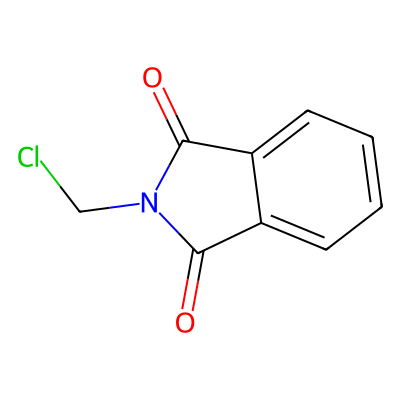

In [71]:
from rdkit import Chem
from rdkit.Chem.Draw import MolToImage

mol = Chem.MolFromSmiles(sample.smiles)
MolToImage(mol, size=(400, 400))

In [72]:
# And to compare the model's prediction against the ground truth for that same molecule:

In [73]:
import torch
true = sample.y.squeeze().tolist()             # 12 values (0, 1, or nan)
probs = predict(model, sample)                 # 12 predicted probabilities

names = [
    "NR-AR", "NR-AR-LBD", "NR-AhR", "NR-Aromatase", "NR-ER", "NR-ER-LBD",
    "NR-PPARγ", "SR-ARE", "SR-ATAD5", "SR-HSE", "SR-MMP", "SR-p53",
]
print(f"SMILES: {sample.smiles}\n")
print(f"{'assay':<14} {'pred':>6}  {'true':>6}")
for n, p, t in zip(names, probs, true):
    t_str = "—" if t != t else int(t)         # NaN check
    print(f"{n:<14} {p:>6.3f}  {str(t_str):>6}")

SMILES: O=C1c2ccccc2C(=O)N1CCl

assay            pred    true
NR-AR           0.044       0
NR-AR-LBD       0.039       0
NR-AhR          0.254       0
NR-Aromatase    0.111       0
NR-ER           0.191       0
NR-ER-LBD       0.076       0
NR-PPARγ        0.060       0
SR-ARE          0.322       0
SR-ATAD5        0.082       0
SR-HSE          0.115       0
SR-MMP          0.308       0
SR-p53          0.150       0


In [74]:
print('''

Atom Input Features Used in the GCN Model

Each atom in a molecule is represented by 9 integer-encoded chemical descriptors stored in data.x.

These features come from OGB’s standard atom_to_feature_vector() function used internally by PyTorch Geometric molecule loaders.

#	Feature	What It Encodes	Example Values
1	Atomic Number	Which chemical element the atom is	6 = C, 7 = N, 8 = O, 16 = S, 17 = Cl
2	Chirality	3D handedness / stereochemistry	0 = none, 1 = R, 2 = S, 3 = other
3	Degree	Number of heavy-atom neighbors bonded to the atom	1, 2, 3, 4
4	Formal Charge	Charge offset (shifted to non-negative integers)	5 = neutral, 4 = −1, 6 = +1
5	Number of Hydrogens	Implicit + explicit attached hydrogens	0, 1, 2, 3
6	Radical Electrons	Number of unpaired electrons	Usually 0
7	Hybridization	Orbital hybridization state	3 = sp², 4 = sp³
8	Is Aromatic	Whether atom belongs to an aromatic system	0 = no, 1 = yes
9	Is in Ring	Whether atom is part of any ring	0 = no, 1 = yes

''')



Atom Input Features Used in the GCN Model

Each atom in a molecule is represented by 9 integer-encoded chemical descriptors stored in data.x.

These features come from OGB’s standard atom_to_feature_vector() function used internally by PyTorch Geometric molecule loaders.

#	Feature	What It Encodes	Example Values
1	Atomic Number	Which chemical element the atom is	6 = C, 7 = N, 8 = O, 16 = S, 17 = Cl
2	Chirality	3D handedness / stereochemistry	0 = none, 1 = R, 2 = S, 3 = other
3	Degree	Number of heavy-atom neighbors bonded to the atom	1, 2, 3, 4
4	Formal Charge	Charge offset (shifted to non-negative integers)	5 = neutral, 4 = −1, 6 = +1
5	Number of Hydrogens	Implicit + explicit attached hydrogens	0, 1, 2, 3
6	Radical Electrons	Number of unpaired electrons	Usually 0
7	Hybridization	Orbital hybridization state	3 = sp², 4 = sp³
8	Is Aromatic	Whether atom belongs to an aromatic system	0 = no, 1 = yes
9	Is in Ring	Whether atom is part of any ring	0 = no, 1 = yes




In [75]:
print('''

Example Atom Encoding

A single atom might be encoded as:

[6, 0, 4, 5, 3, 0, 4, 0, 0]

This corresponds to:

Position	Meaning	Interpretation
1	6	Carbon atom
2	0	No chirality
3	4	Four bonded neighbors
4	5	Neutral formal charge
5	3	Three hydrogens attached
6	0	No radical electrons
7	4	sp³ hybridization
8	0	Non-aromatic
9	0	Not in a ring

So chemically this represents a typical methyl carbon (-CH₃).

Additional Graph Information

Besides atom features, the molecular graph also contains connectivity information:

Component	Purpose	Used by Vanilla GCNConv?
edge_index	Graph topology (which atoms are bonded)	✅ Yes
edge_attr	Bond features (bond type, stereo, conjugation)	❌ No
edge_index

This defines the molecular connectivity:

edge_index = [[0,1],
              [1,0]]

Meaning:

atom 0 connected to atom 1
atom 1 connected to atom 0

This is the structure over which message passing occurs.

Bond Features (edge_attr)

The graph may also store:

Bond Feature	Meaning
Bond type	single, double, triple, aromatic
Bond stereo	cis/trans stereochemistry
Is conjugated	whether bond participates in conjugation

However, a standard GCNConv layer ignores these bond attributes.

To actually use bond features, models such as these are needed:

Layer Type	Uses Bond Features?
GCNConv	❌ No
GINEConv	✅ Yes
NNConv	✅ Yes
MPNN variants	✅ Yes
Effective Input to This Particular Model

So for this vanilla GCN architecture, the model learns from:

9 atom-level chemical descriptors
Graph topology (edge_index)

while bond attributes are present but unused.

''')



Example Atom Encoding

A single atom might be encoded as:

[6, 0, 4, 5, 3, 0, 4, 0, 0]

This corresponds to:

Position	Meaning	Interpretation
1	6	Carbon atom
2	0	No chirality
3	4	Four bonded neighbors
4	5	Neutral formal charge
5	3	Three hydrogens attached
6	0	No radical electrons
7	4	sp³ hybridization
8	0	Non-aromatic
9	0	Not in a ring

So chemically this represents a typical methyl carbon (-CH₃).

Additional Graph Information

Besides atom features, the molecular graph also contains connectivity information:

Component	Purpose	Used by Vanilla GCNConv?
edge_index	Graph topology (which atoms are bonded)	✅ Yes
edge_attr	Bond features (bond type, stereo, conjugation)	❌ No
edge_index

This defines the molecular connectivity:

edge_index = [[0,1],
              [1,0]]

Meaning:

atom 0 connected to atom 1
atom 1 connected to atom 0

This is the structure over which message passing occurs.

Bond Features (edge_attr)

The graph may also store:

Bond Feature	Meaning
Bond type	single, double,

In [76]:
print('''

Output Features (Per Molecule)

The model outputs a 12-dimensional vector, where each value corresponds to one Tox21 toxicity assay.

These outputs are produced by the final layer:

Linear(32, 12)

Each output is a raw logit:

positive value → higher predicted probability of activity
negative value → lower predicted probability
near zero → uncertain / ~50%

To convert logits into probabilities:

probabilities = torch.sigmoid(logits)

During training, this sigmoid transformation is handled internally by:

BCEWithLogitsLoss

The 12 Toxicity Outputs

#	Output	Pathway Type	Biological Meaning
1	NR-AR	Nuclear receptor	Androgen receptor activity
2	NR-AR-LBD	Nuclear receptor	Androgen receptor ligand binding
3	NR-AhR	Nuclear receptor	Aryl hydrocarbon receptor (dioxin-like signaling)
4	NR-Aromatase	Nuclear receptor	Estrogen synthesis enzyme activity
5	NR-ER	Nuclear receptor	Estrogen receptor activity
6	NR-ER-LBD	Nuclear receptor	Estrogen receptor ligand binding
7	NR-PPAR-γ	Nuclear receptor	Metabolism and lipid regulation
8	SR-ARE	Stress response	Oxidative stress response
9	SR-ATAD5	Stress response	DNA damage / genomic instability
10	SR-HSE	Stress response	Heat shock / protein misfolding
11	SR-MMP	Stress response	Mitochondrial membrane disruption
12	SR-p53	Stress response	Tumor suppressor / cellular stress
Example Output Vector

Example raw logits:

[-2.1, -1.7, 3.2, 0.4, -0.9, -1.3,
 -2.5, 2.8, -0.4, -3.1, -1.2, 0.7]

After sigmoid conversion:

[0.11, 0.15, 0.96, 0.60, 0.29, 0.21,
 0.08, 0.94, 0.40, 0.04, 0.23, 0.67]

Interpretation:

Strong activity predicted for:
NR-AhR
SR-ARE
Moderate activity for:
SR-p53
Mostly inactive elsewhere

Important: This Is Multi-Label Classification

This is not a single 12-class prediction problem.

Instead, each assay is an independent binary classification:

Molecule	NR-AR	NR-AhR	SR-ARE	SR-p53
Molecule A	0	1	1	0
Molecule B	0	0	0	0
Molecule C	1	1	0	1

A molecule may:

activate multiple pathways simultaneously
activate none
activate only one

That is why the model uses:

BCEWithLogitsLoss

instead of:

CrossEntropyLoss

''')



Output Features (Per Molecule)

The model outputs a 12-dimensional vector, where each value corresponds to one Tox21 toxicity assay.

These outputs are produced by the final layer:

Linear(32, 12)

Each output is a raw logit:

positive value → higher predicted probability of activity
negative value → lower predicted probability
near zero → uncertain / ~50%

To convert logits into probabilities:

probabilities = torch.sigmoid(logits)

During training, this sigmoid transformation is handled internally by:

BCEWithLogitsLoss

The 12 Toxicity Outputs

#	Output	Pathway Type	Biological Meaning
1	NR-AR	Nuclear receptor	Androgen receptor activity
2	NR-AR-LBD	Nuclear receptor	Androgen receptor ligand binding
3	NR-AhR	Nuclear receptor	Aryl hydrocarbon receptor (dioxin-like signaling)
4	NR-Aromatase	Nuclear receptor	Estrogen synthesis enzyme activity
5	NR-ER	Nuclear receptor	Estrogen receptor activity
6	NR-ER-LBD	Nuclear receptor	Estrogen receptor ligand binding
7	NR-PPAR-γ	Nuclear receptor	Met

In [77]:
print('''

The model takes the 9-integer-per-atom input, expands it through embeddings into a 32-float-per-atom continuous representation, 
runs three graph convolution layers that mix in neighbour information along bonds, averages all the atoms together into one 
32-dim molecule vector, and projects that to the 12 output logits. 

''')



The model takes the 9-integer-per-atom input, expands it through embeddings into a 32-float-per-atom continuous representation, 
runs three graph convolution layers that mix in neighbour information along bonds, averages all the atoms together into one 
32-dim molecule vector, and projects that to the 12 output logits. 




In [78]:
print('''

Transformations :

Input per molecule:
[num_atoms, 9]                 integers
(raw atom chemistry features)
        ↓
AtomEncoder
        ↓
[num_atoms, 32]                floats
(atom embeddings)
        ↓
3 × GCNConv
(message passing through bonds)
        ↓
[num_atoms, 32]                floats
(context-aware atom embeddings)
        ↓
global_mean_pool
(collapse all atoms into one molecule vector)
        ↓
[32]                           floats
(single molecule representation)
        ↓
Linear(32 → 12)
        ↓
Output per molecule:
[12]                           floats
(toxicity logits)

''')



Transformations :

Input per molecule:
[num_atoms, 9]                 integers
(raw atom chemistry features)
        ↓
AtomEncoder
        ↓
[num_atoms, 32]                floats
(atom embeddings)
        ↓
3 × GCNConv
(message passing through bonds)
        ↓
[num_atoms, 32]                floats
(context-aware atom embeddings)
        ↓
global_mean_pool
(collapse all atoms into one molecule vector)
        ↓
[32]                           floats
(single molecule representation)
        ↓
Linear(32 → 12)
        ↓
Output per molecule:
[12]                           floats
(toxicity logits)


